In [ ]:
from Bio import Align
from collections import Counter
import numpy as np
from collections import defaultdict
import csv
import json
import sqlite3
from pathlib import Path
from natsort import natsorted
from src.similarity_matrix import create_slices
from rapidfuzz import fuzz, distance, process
from matplotlib import pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from copy import deepcopy

from src.csv_pages_to_names import read_files
from src.name_cleanup import get_cleaned_full_name_db
from src.similarity_matrix import create_sim_m, reciprocal_best_matches
from src.count_confused_characters import (
    align_characters,
    pad_alignments,
    update_confusion_counter,
    counter_to_matrix,
)

## OCR read parishes to DB parishes

## Loading data

In [2]:
book_data_base_dir = Path("data/migration-data-csv-release-v1")
database_path = Path("data/all_hiski_records.sqlite3")
book_info_path = Path("outputs/json/book_info.json")
places_new_db_path = Path("data/csv/places_from_new_db.tsv")
extra_place_names = Path("data/json/placenames.jsonl")
year_predictions = Path("data/year-predictions")
print_metadata_path = Path("data/csv/prints_meta.csv")
output_file = Path("")

table_cols = (
    "event_id",
    "dep_day", "dep_month", "dep_year",
    "arr_day", "arr_month", "arr_year",
    "destination/source", "village", "house",
    "profession", "first_name", "patronym", "last_name", "etc",
    "village_id", "parish_id",
    "destinationN/sourceN",
    "first_nameN", "patronymN", "last_nameN",
)

In [3]:
connection = sqlite3.connect(database_path)
cursor = connection.cursor()

### Get print metadata and book info

In [4]:
print_metadata_dict = defaultdict(list)
with open(print_metadata_path, mode="r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        pid = row["print_id"]
        direction = row["direction"]
        side = row["side"]
        mapped_side = "both" if side == "single" else side
        print_metadata_dict[pid].append((direction, mapped_side))

In [5]:
with open(book_info_path, "r") as fp:
    book_info = json.load(fp)

### Select book for testing

In [6]:
def get_info_for_book(book):
    parish = book["parish_normalized"].lower()
    parish_id = book["parish_id"]
    year_start = book["year_1"]
    year_end = book["year_2"]
    source_type = book["source"].lower()
    classification = book["luokittelu"].lower()

    return {
        "parish": parish,
        "parish_id": parish_id,
        "year_start": year_start,
        "year_end": year_end,
        "source_type": source_type,
        "classification": classification,
        "ocr_files_dir_name": book_data_base_dir/f"{parish}/muuttaneet_{year_start}-{year_end}_{source_type}",
        "book_year_predictions_path": year_predictions / f"{parish}_muuttaneet_{year_start}-{year_end}_{source_type}.jsonl"
    }

info_for_book = get_info_for_book(book_info[0])

### Get year prediction data for book

In [7]:
def get_page_side_to_year(book_year_predictions_path):
    p_s_combination_to_year = {}
    with open(book_year_predictions_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            record = json.loads(line)
            corrected = record.get("corrected")
            if corrected is None:
                continue
            corrected_str = str(corrected)
            if not corrected_str.isnumeric():
                continue
            key = f"{record['page']}_{record['side']}"
            p_s_combination_to_year[key] = int(corrected)
    return p_s_combination_to_year

### OCR-data / csv-files

In [8]:
def path_to_page_size(filepath):
    p = Path(filepath)
    name = p.stem
    return "left" if "left" in name else "right"

def path_to_page_number(filepath):
    p = Path(filepath)
    name = p.stem
    return int(name.split("_")[-3])

### Events from database

In [9]:
def get_parish_events_with_year_match(cursor, info_for_book, p_s_combination_to_year, year_window_radius):
    year_low_bound = min(p_s_combination_to_year.values()) - year_window_radius
    year_high_bound = max(p_s_combination_to_year.values()) + year_window_radius
    query = f"""
        SELECT * FROM emigrated WHERE parish_id={info_for_book["parish_id"]}
        AND (dep_year>={year_low_bound} AND {year_high_bound}>=dep_year);
    """

    cursor.execute(query)
    parish_events_with_year_match = cursor.fetchall()

    return parish_events_with_year_match

In [10]:
def create_event_dict(row, table_cols):
    return {
        col: "" if value is None else value
        for col, value in zip(table_cols, row)
    }

## DB written sources/destinations to OCR spellings

### Using confirmed name matches

In [11]:
def gather_rbm_result(
    rbm,
    ocr_page_names,
    ocr_blocks,
    db_blocks,
    csv_files_sorted,
    db_included_event_ids,
):
    rbm_result = []
    for db_i, ocr_i in zip(*np.nonzero(rbm)):
        p, r = ocr_page_names[ocr_i][1:]
        rbm_result.append(
            {
                "ocr_name": ocr_blocks[ocr_i],
                "db_name": db_blocks[db_i],
                "ocr_row": ocr_pages[p][r][0],
                "ocr_file": csv_files_sorted[p],
                "ocr_file_idx": p,
                "ocr_row_idx": r,
                "db_event_id": db_included_event_ids[db_i],
            }
        )
    return rbm_result


def find_confirmed_pairs(
    ocr_names,
    csv_files_side,
    csv_files_page,
    p_s_combination_to_year,
    year_to_names,
    year_to_event_ids,
    year_window_radius
):
    results = []
    for ocr_page_names, side, page in zip(
        ocr_names, csv_files_side, csv_files_page
    ):
        year = p_s_combination_to_year.get(f"{page}_{side}", None)

        if not year:
            continue

        db_names_to_include = (
            year_to_names.get(year - year_window_radius, [])
            + year_to_names[year]
            + year_to_names.get(year + year_window_radius, [])
        )
        db_included_event_ids = (
            year_to_event_ids.get(year - 1, [])
            + year_to_event_ids[year]
            + year_to_event_ids.get(year + 1, [])
        )

        ocr_names_to_include = tuple(n[0] for n in ocr_page_names)

        if len(db_names_to_include) == 0 or len(ocr_names_to_include) == 0:
            continue

        db_blocks, db_ranges = create_slices(db_names_to_include, 1, 1)
        ocr_blocks, ocr_ranges = create_slices(ocr_names_to_include, 1, 1)

        sim_m, individual_scores = create_sim_m(
            a_slices=db_blocks,
            b_slices=ocr_blocks,
            scorer=fuzz.ratio,
            join_char=" | ",
        )

        rbm = reciprocal_best_matches(sim_m)

        if rbm.max() > 0.85:
            results += gather_rbm_result(
                rbm,
                ocr_page_names,
                ocr_blocks,
                db_blocks,
                csv_files_sorted,
                db_included_event_ids,
            )

    return results

## Going through books

In [ ]:
all_book_dict = defaultdict(list)

for book in tqdm(book_info):
    info_for_book = get_info_for_book(book)

    if not info_for_book["book_year_predictions_path"].exists():
        continue

    p_s_combination_to_year = get_page_side_to_year(
        info_for_book["book_year_predictions_path"]
    )

    if len(p_s_combination_to_year) == 0:
        continue

    csv_files_sorted = natsorted(
        map(str, info_for_book["ocr_files_dir_name"].glob("*.csv"))
    )
    ocr_pages, ocr_names = read_files(csv_files_sorted)

    if len(ocr_pages) == 0:
        continue

    csv_files_side = tuple(map(path_to_page_size, csv_files_sorted))
    csv_files_page = tuple(map(path_to_page_number, csv_files_sorted))

    parish_events_with_year_match = get_parish_events_with_year_match(
        cursor, info_for_book, p_s_combination_to_year, 1
    )

    if len(parish_events_with_year_match) == 0:
        continue

    year_to_event_ids = defaultdict(list)
    year_to_names = defaultdict(list)
    events = {}

    for row in parish_events_with_year_match:
        event = create_event_dict(row, table_cols)
        event_id = event["event_id"]
        departure_year = event["dep_year"]
        full_name = get_cleaned_full_name_db(event)

        year_to_names[departure_year].append(full_name)
        year_to_event_ids[departure_year].append(event_id)
        events[event_id] = event

    dicts_for_info = find_confirmed_pairs(
        ocr_names,
        csv_files_side,
        csv_files_page,
        p_s_combination_to_year,
        year_to_names,
        year_to_event_ids,
        1,
    )

    for info_dict in dicts_for_info:
        db_place = events[info_dict["db_event_id"]]["destination/source"]
        ocr_place = process.extractOne(
            db_place,
            info_dict["ocr_row"],
            scorer=distance.Levenshtein.normalized_similarity,
            score_cutoff=0.4,
        )
        if ocr_place == None:
            continue
        all_book_dict[db_place].append(
            {
                "ocr_read_spelling": ocr_place[0],
                "score": ocr_place[1],
                "file": info_dict["ocr_file"],
                "file_idx": info_dict["ocr_file_idx"],
                "row_idx": info_dict["ocr_row_idx"],
            }
        )

  0%|          | 0/2781 [00:00<?, ?it/s]

In [31]:
def format_json(data, indent=4):
    def format_list(lst, level):
        items = ", ".join(json.dumps(x, ensure_ascii=False) for x in lst)
        return f"[{items}]"

    lines = ["{"]
    keys = list(data.keys())
    for i, key in enumerate(keys):
        key_str = json.dumps(key, ensure_ascii=False)
        lines.append(f'{" " * indent}{key_str}: [')
        entries = data[key]
        for j, entry in enumerate(entries):
            comma = "," if j < len(entries) - 1 else ""
            lines.append(f'{" " * indent * 2}{format_list(entry, 2)}{comma}')
        comma = "," if i < len(keys) - 1 else ""
        lines.append(f'{" " * indent}]{comma}')
    lines.append("}")
    return "\n".join(lines)

In [111]:
spellings_counts = defaultdict(Counter)
for k, spelling_list in all_book_dict.items():
    spellings_counts[k].update(
        (s["ocr_read_spelling"], s["score"]) for s in spelling_list
    )


In [ ]:
spellings = {
    place: tuple(s + (c,) for s, c in spelling_counter.most_common())
    for place, spelling_counter in spellings_counts.items()
}

In [135]:
with open("outputs/json/ocr_places_spellings.json", "w") as fp:
    fp.write(format_json(spellings))

## Analyzing which characters get mixed up

In [13]:
aligner = Align.PairwiseAligner(mode="global")

In [14]:
confusion_counter = defaultdict(Counter)
confusion_counter_exclude_self = defaultdict(Counter)
gathered_alignments = {}
for place, spellings in all_book_dict.items():
    place_spellings = tuple(list(s) for pl in spellings if (s := pl["ocr_read_spelling"]))

    if len(place_spellings) == 0:
        continue

    place_alignments, spelling_alignments = align_characters(place, place_spellings, aligner)
    place_alignments, spelling_alignments = pad_alignments(place_alignments, spelling_alignments)

    update_confusion_counter(
        confusion_counter,
        zip(place_alignments, spelling_alignments),
    )
    
    gathered_alignments[place] = list(zip(place_alignments, spelling_alignments))


confusion_counter_exclude_self = deepcopy(confusion_counter)
for character, character_counter in confusion_counter_exclude_self.items():
    del character_counter[character]

In [15]:
chars = "abcdefghijklmnopqrstuvwxyzåäö"

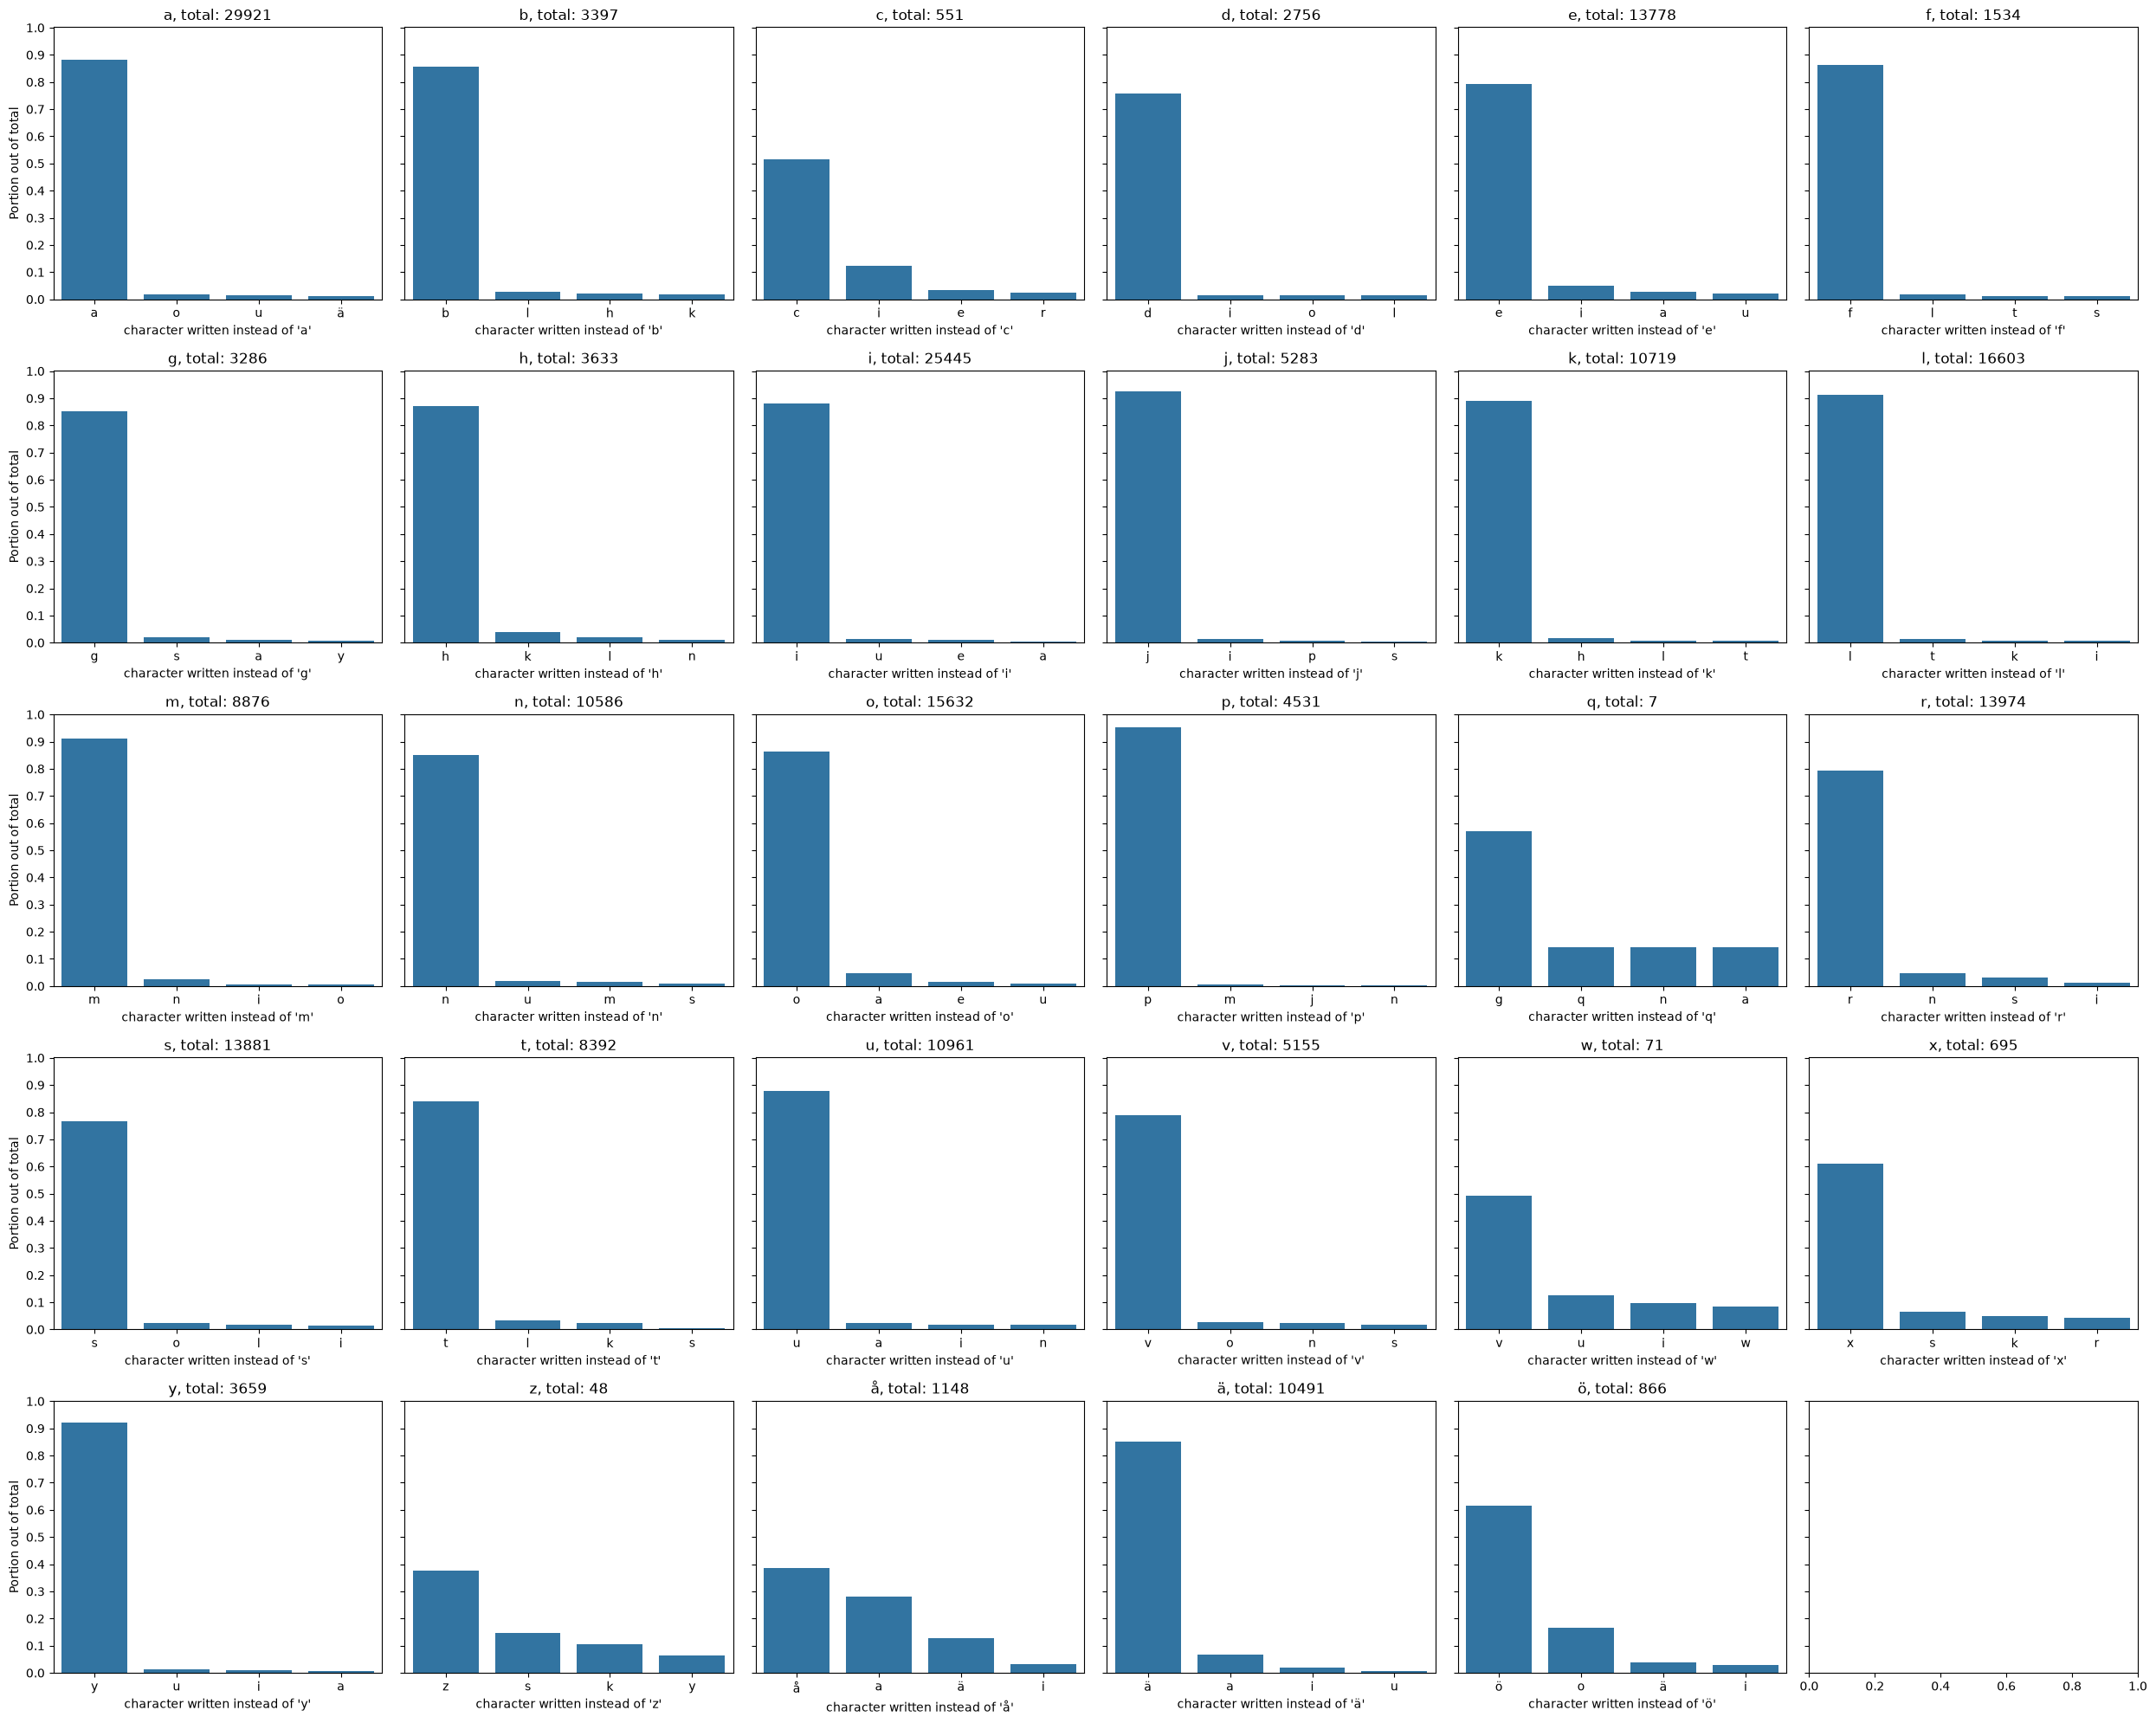

In [16]:
fig, axs = plt.subplots(5, 6, figsize=(25, 20), sharey=True)

for ax in axs:
    ax[0].set_ylabel(f"Portion out of total")

for i, ax in enumerate(axs.flat):
    if i >= len(chars):
        break
    char = chars[i]
    sns.barplot(
        {c: count / confusion_counter[char].total() for c, count in confusion_counter[char].most_common(5)},
        ax=ax,
    )
    ax.set_yticks(tuple(i*0.1 for i in range(0, 11, 1)))
    ax.set_title(f"{char}, total: {confusion_counter[char].total()}")
    ax.set_xlabel(f"character written instead of '{char}'")

plt.tight_layout()

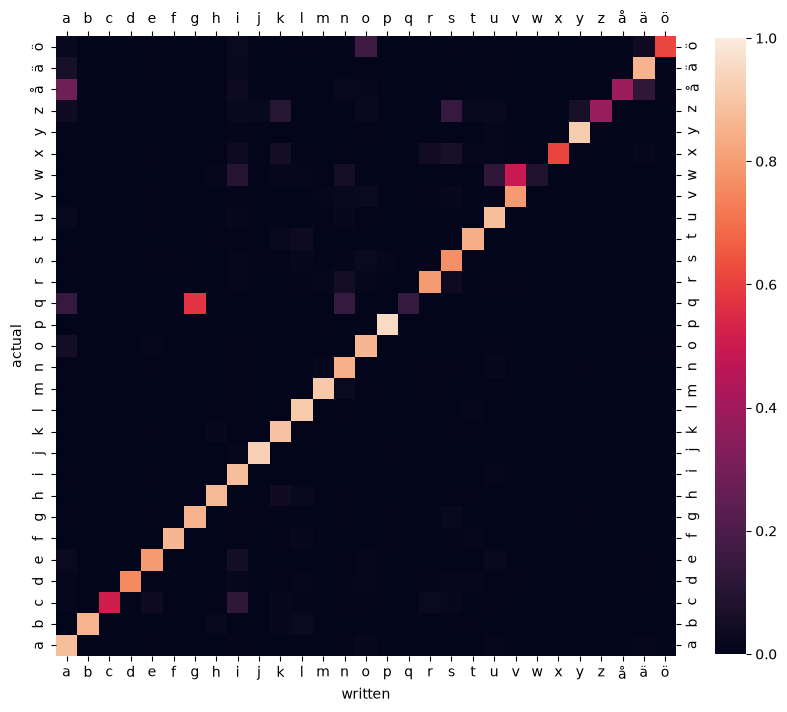

In [17]:
heatmap = counter_to_matrix(chars, confusion_counter)

plt.subplots(figsize=(10, 10))
ax = sns.heatmap(
    heatmap,
    xticklabels=chars, yticklabels=chars,
    square=True,
    vmin=0, vmax=1,
    cbar_kws={"shrink": 0.8},
)
ax.tick_params(
    labelbottom=True, labeltop=True, labelleft=True, labelright=True,
    bottom=True, top=True, left=True, right=True,
)
ax.set_ylabel("actual")
ax.set_xlabel("written")
ax.invert_yaxis()

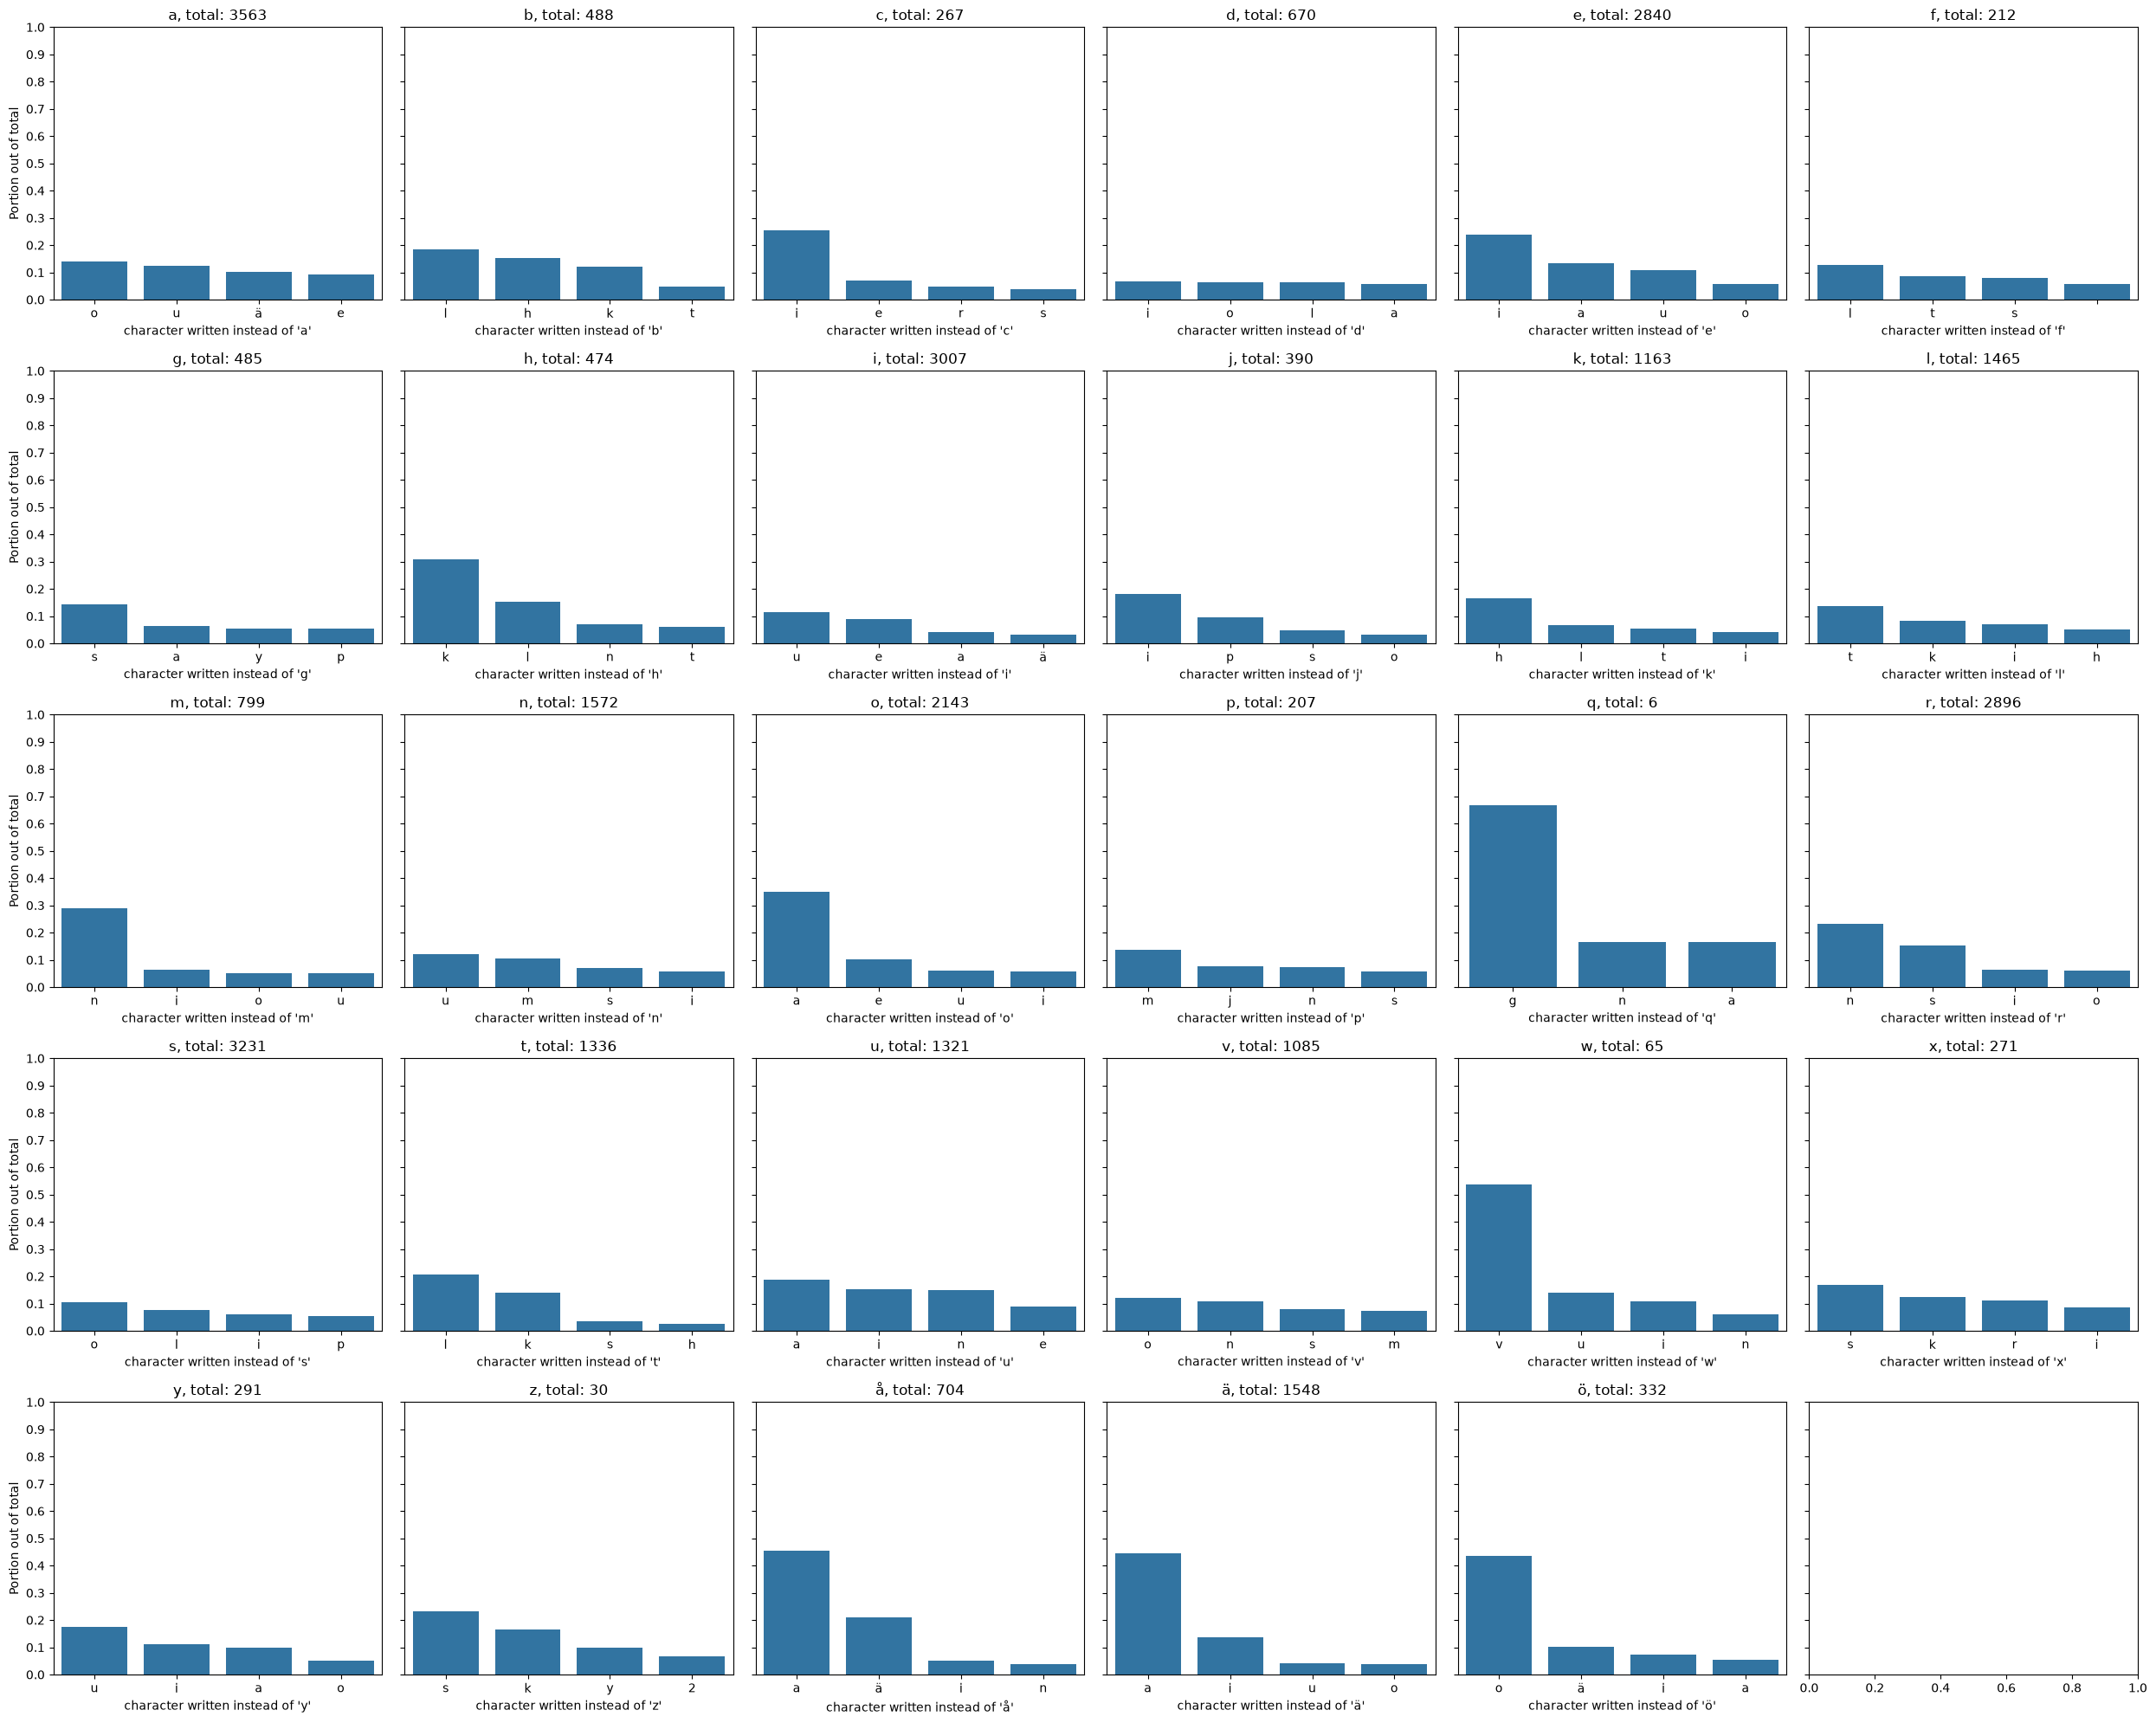

In [ ]:
fig, axs = plt.subplots(5, 6, figsize=(25, 20), sharey=True)

for ax in axs:
    ax[0].set_ylabel(f"Portion out of total")

for i, ax in enumerate(axs.flat):
    if i >= len(chars):
        break
    char = chars[i]
    sns.barplot(
        {
            c: count / confusion_counter_exclude_self[char].total()
            for c, count in confusion_counter_exclude_self[char].most_common(5)
        },
        ax=ax,
    )
    ax.set_yticks(tuple(i * 0.1 for i in range(0, 11, 1)))
    ax.set_title(
        f"{char}, total: {confusion_counter_exclude_self[char].total()}"
    )
    ax.set_xlabel(f"character written instead of '{char}'")

plt.tight_layout()

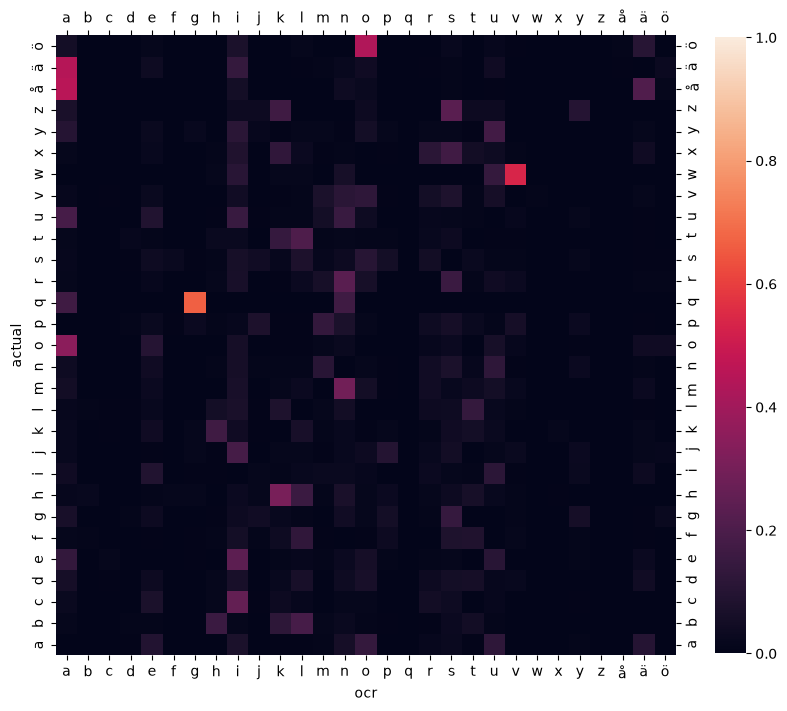

In [19]:
heatmap = counter_to_matrix(chars, confusion_counter_exclude_self, True)

plt.subplots(figsize=(10, 10))
ax = sns.heatmap(
    heatmap,
    xticklabels=chars, yticklabels=chars,
    square=True,
    vmin=0, vmax=1,
    cbar_kws={"shrink": 0.8},
)
ax.tick_params(
    labelbottom=True, labeltop=True, labelleft=True, labelright=True,
    bottom=True, top=True, left=True, right=True,
)
ax.set_ylabel("actual")
ax.set_xlabel("ocr")
ax.invert_yaxis()